In [ ]:
# ===============================
# 1️⃣ ENVIRONMENT SETUP
# ===============================

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install pennylane torch torchvision scikit-learn matplotlib seaborn tqdm --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import pennylane as qml
from pennylane import numpy as pnp

device = torch.device("cpu")  # CPU runtime
print("Using device:", device)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 119.3 MB/s eta 0:00:00
Using device: cpu


In [ ]:
# ===============================
# 2️⃣ DATASET INFORMATION (FIXED)
# ===============================

SUIM_PATH = "/content/drive/MyDrive/SUIM"

TRAIN_IMG_PATH = os.path.join(SUIM_PATH, "train_val/images")
TRAIN_MASK_PATH = os.path.join(SUIM_PATH, "train_val/masks")

TEST_IMG_PATH = os.path.join(SUIM_PATH, "TEST/images")
TEST_MASK_PATH = os.path.join(SUIM_PATH, "TEST/masks")

# Only take directories (ignore .bmp files)
CLASS_NAMES = sorted([
    d for d in os.listdir(TEST_MASK_PATH)
    if os.path.isdir(os.path.join(TEST_MASK_PATH, d))
])

NUM_CLASSES = len(CLASS_NAMES)

print("Detected Classes:", CLASS_NAMES)
print("Total Classes:", NUM_CLASSES)

Detected Classes: ['FV', 'HD', 'PF', 'RI', 'RO', 'SR', 'Saliency', 'WR']
Total Classes: 8


In [ ]:
# ===============================
# 3️⃣ SEGMENTATION → CLASSIFICATION
# ===============================

from PIL import Image
from collections import Counter

def get_dominant_class_from_rgb_mask(mask_path):
    mask = np.array(Image.open(mask_path))
    pixels = mask.reshape(-1, 3)
    unique, counts = np.unique(pixels, axis=0, return_counts=True)
    dominant = unique[np.argmax(counts)]
    return tuple(dominant)

# Build RGB → class index mapping
rgb_to_index = {}
current_index = 0

image_files = sorted(os.listdir(TRAIN_IMG_PATH))
labels_list = []

print("Generating labels...")

for img_name in tqdm(image_files):
    mask_name = img_name.replace(".jpg", ".bmp")
    mask_path = os.path.join(TRAIN_MASK_PATH, mask_name)

    dominant_rgb = get_dominant_class_from_rgb_mask(mask_path)

    if dominant_rgb not in rgb_to_index:
        rgb_to_index[dominant_rgb] = current_index
        current_index += 1

    labels_list.append(rgb_to_index[dominant_rgb])

print("Detected Classes:", len(rgb_to_index))

Generating labels...


100%|██████████| 1525/1525 [24:20<00:00,  1.04it/s]

Detected Classes: 8


In [ ]:
# 4️⃣ DATASET CLASS
# ===============================

class SUIMDataset(Dataset):
    def __init__(self, image_list, label_list, transform=None):
        self.image_list = image_list
        self.label_list = label_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path = os.path.join(TRAIN_IMG_PATH, self.image_list[idx])
        image = Image.open(img_path).convert("RGB")
        label = self.label_list[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# DATA PREPROCESSING
# ===============================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# ===============================
# 6️⃣ CLASS IMBALANCE HANDLING
# ===============================

class_counts = Counter(labels_list)
total_samples = len(labels_list)

class_weights = []
for i in range(NUM_CLASSES):
    count = class_counts[i]
    weight = total_samples / (NUM_CLASSES * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([ 0.4323,  1.4333,  0.2919, 10.0329,  0.8992, 95.3125,  4.5387,  8.2880])


In [ ]:
# 7️⃣ STRATIFIED K-FOLD
# ===============================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# ===============================
# 8️⃣ CLASSICAL MODELS
# ===============================

def get_resnet18():
    model = models.resnet18(weights="IMAGENET1K_V1")
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model

def get_mobilenet():
    model = models.mobilenet_v2(weights="IMAGENET1K_V1")
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    return model

def get_efficientnet():
    model = models.efficientnet_b0(weights="IMAGENET1K_V1")
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    return model

class ShallowCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*56*56, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# QUANTUM LAYERS BELOW (4 AND 8 QUBITS)

In [ ]:
# ===============================
# 9️⃣ HYBRID MODEL — 4 QUBITS
# ===============================

n_qubits_4 = 4
dev4 = qml.device("default.qubit", wires=n_qubits_4)

@qml.qnode(dev4, interface="torch", diff_method="backprop")
def quantum_circuit_4(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits_4))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits_4))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_4)]

weight_shapes_4 = {"weights": (3, n_qubits_4, 3)}

class HybridModel4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights="IMAGENET1K_V1")
        for param in self.backbone.parameters():
            param.requires_grad = False
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.fc_reduce = nn.Linear(in_features, n_qubits_4)
        self.tanh = nn.Tanh()

        self.qlayer = qml.qnn.TorchLayer(quantum_circuit_4, weight_shapes_4)

        self.classifier = nn.Linear(n_qubits_4, NUM_CLASSES)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc_reduce(x)
        x = self.tanh(x)
        x = self.qlayer(x)
        x = self.classifier(x)
        return x

In [ ]:
# ===============================
# 🔟 HYBRID MODEL — 8 QUBITS
# ===============================

n_qubits_8 = 8
dev8 = qml.device("default.qubit", wires=n_qubits_8)

@qml.qnode(dev8, interface="torch", diff_method="backprop")
def quantum_circuit_8(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits_8))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits_8))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits_8)]

weight_shapes_8 = {"weights": (3, n_qubits_8, 3)}

class HybridModel8Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights="IMAGENET1K_V1")
        for param in self.backbone.parameters():
            param.requires_grad = False
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.fc_reduce = nn.Linear(in_features, n_qubits_8)
        self.tanh = nn.Tanh()

        self.qlayer = qml.qnn.TorchLayer(quantum_circuit_8, weight_shapes_8)

        self.classifier = nn.Linear(n_qubits_8, NUM_CLASSES)

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc_reduce(x)
        x = self.tanh(x)
        x = self.qlayer(x)
        x = self.classifier(x)
        return x

In [ ]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, epochs=10):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion) # Call the new evaluate_model function

        history["train_loss"].append(train_loss/len(train_loader))
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [ ]:
# 1️⃣3️⃣ STANDARD SPLIT
# ===============================

train_imgs, test_imgs, train_labels, test_labels = train_test_split(
    image_files, labels_list, test_size=0.15,
    stratify=labels_list, random_state=42)

train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    train_imgs, train_labels, test_size=0.176,
    stratify=train_labels, random_state=42)

train_dataset = SUIMDataset(train_imgs, train_labels, train_transform)
val_dataset = SUIMDataset(val_imgs, val_labels, val_transform)
test_dataset = SUIMDataset(test_imgs, test_labels, val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
# 1️⃣4️⃣ TRAIN RESNET18
# ===============================

resnet_model = get_resnet18()
resnet_history = train_model(resnet_model, train_loader, val_loader, epochs=10)

Epoch 1/10 | Train Acc: 0.1640 | Val Acc: 0.2533
Epoch 2/10 | Train Acc: 0.3243 | Val Acc: 0.2795
Epoch 3/10 | Train Acc: 0.3261 | Val Acc: 0.3537
Epoch 4/10 | Train Acc: 0.4133 | Val Acc: 0.4847
Epoch 5/10 | Train Acc: 0.4827 | Val Acc: 0.4498
Epoch 6/10 | Train Acc: 0.4217 | Val Acc: 0.5066
Epoch 7/10 | Train Acc: 0.5127 | Val Acc: 0.5197
Epoch 8/10 | Train Acc: 0.4920 | Val Acc: 0.5240
Epoch 9/10 | Train Acc: 0.5501 | Val Acc: 0.6070
Epoch 10/10 | Train Acc: 0.5314 | Val Acc: 0.5721


In [ ]:
# 🔷 CELL 15 — Evaluation Function

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def evaluate_model(model, test_loader, device, num_classes=8):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print("\n🔹 Test Results")
    print("Accuracy :", acc)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    return all_labels, all_preds, np.array(all_probs)

# CHECK HOW TO RUN REST OF THE CLASSICAL AND HYBRID MODELS
    * RESNET18 DONE
    * PENDING TO TRAIN AND GET RESULTS: MOBILENET, EFFICIENTNET, SHALLOWCNN, HYBRIDQUAMTUM_4 AND HYBRIDQUANTUM_8

  

In [ ]:
# # labels_mobilenet, preds_mobilenet, probs_mobilenet = evaluate_model(get_mobilenet, test_loader, device)
# labels_efficientnet, preds_efficientnet, probs_efficientnet = evaluate_model(get_efficientnet, test_loader, device)
# # labels_shallow, preds_shallow, probs_shallow = evaluate_model(shallow_model, test_loader, device)
# labels_hybrid4, preds_hybrid4, probs_hybrid4 = evaluate_model(quantum_circuit_4, test_loader, device)
# labels_hybrid8, preds_hybrid8, probs_hybrid8 = evaluate_model(quantum_circuit_8, test_loader, device)

# Results section

In [ ]:
labels_resnet, preds_resnet, probs_resnet = evaluate_model(resnet_model, test_loader, device)


🔹 Test Results
Accuracy : 0.5240174672489083
Precision: 0.3153396377062186
Recall   : 0.30646479370969165
F1 Score : 0.2971757558428439

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.35      0.47        66
           1       0.45      0.50      0.48        20
           2       0.68      0.76      0.71        98
           3       0.00      0.00      0.00         3
           4       0.29      0.38      0.33        32
           6       0.06      0.17      0.09         6
           7       0.00      0.00      0.00         4

    accuracy                           0.52       229
   macro avg       0.32      0.31      0.30       229
weighted avg       0.58      0.52      0.53       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

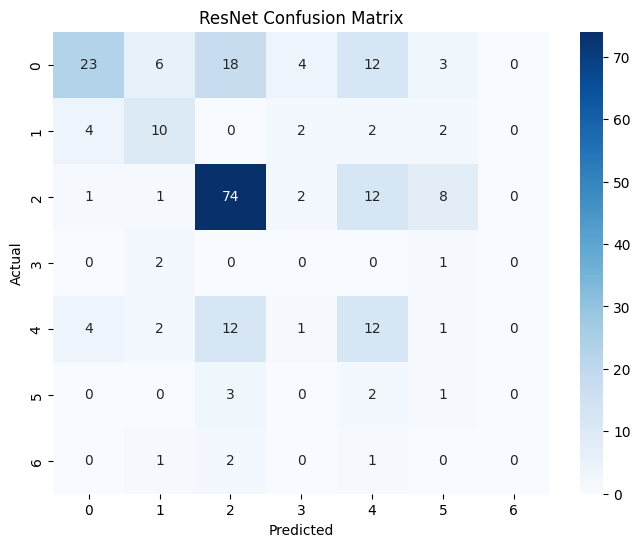

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


plot_confusion_matrix(labels_resnet, preds_resnet, "ResNet Confusion Matrix")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


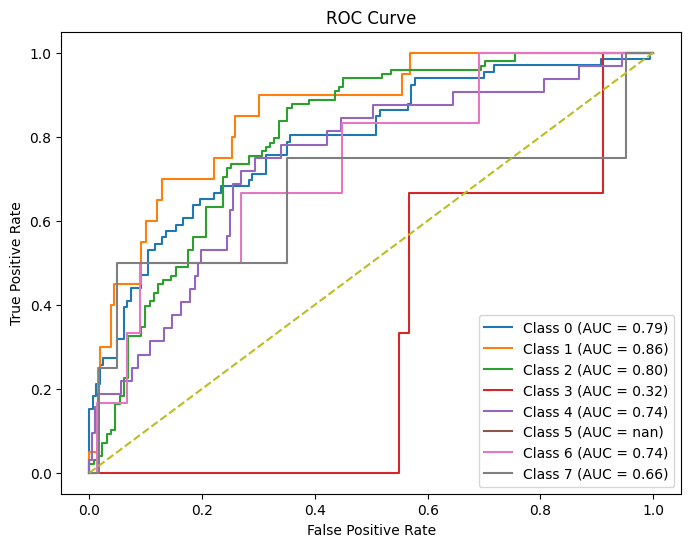

In [ ]:
def plot_multiclass_roc(true_labels, probs, num_classes=8, title="ROC Curve"):

    true_bin = label_binarize(true_labels, classes=list(range(num_classes)))

    plt.figure(figsize=(8,6))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(true_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

plot_multiclass_roc(labels_resnet, probs_resnet)

# FOR EXAMPLE ONLY (NOT THE ACTUAL OUTPUT)

In [ ]:
# def compare_models(metrics_dict):
#     models = list(metrics_dict.keys())
#     precision = [metrics_dict[m]['precision'] for m in models]
#     recall = [metrics_dict[m]['recall'] for m in models]
#     f1 = [metrics_dict[m]['f1'] for m in models]

#     x = np.arange(len(models))

#     width = 0.2

#     plt.figure(figsize=(10,6))
#     plt.bar(x - width, precision, width, label='Precision')
#     plt.bar(x, recall, width, label='Recall')
#     plt.bar(x + width, f1, width, label='F1')

#     plt.xticks(x, models, rotation=45)
#     plt.legend()
#     plt.title("Model Comparison")
#     plt.show()

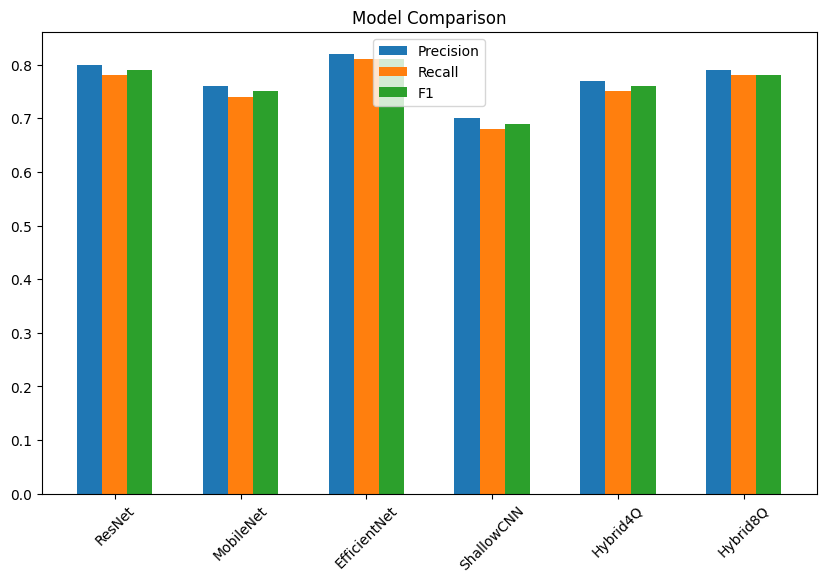

In [ ]:
# metrics_dict = {
#     "ResNet": {"precision":0.80, "recall":0.78, "f1":0.79},
#     "MobileNet": {"precision":0.76, "recall":0.74, "f1":0.75},
#     "EfficientNet": {"precision":0.82, "recall":0.81, "f1":0.81},
#     "ShallowCNN": {"precision":0.70, "recall":0.68, "f1":0.69},
#     "Hybrid4Q": {"precision":0.77, "recall":0.75, "f1":0.76},
#     "Hybrid8Q": {"precision":0.79, "recall":0.78, "f1":0.78}
# }

# compare_models(metrics_dict)

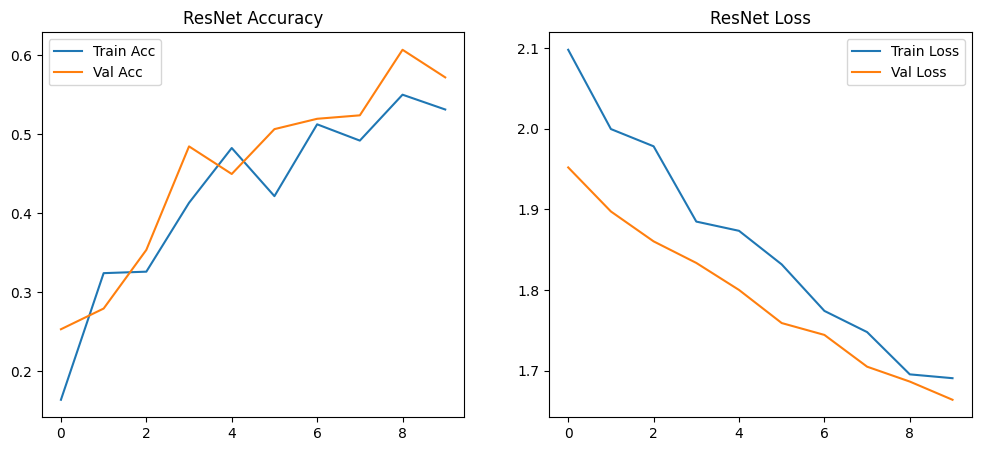

In [ ]:
def plot_training_history(history, title):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history['train_acc'], label="Train Acc")
    plt.plot(history['val_acc'], label="Val Acc")
    plt.legend()
    plt.title(f"{title} Accuracy")

    plt.subplot(1,2,2)
    plt.plot(history['train_loss'], label="Train Loss")
    plt.plot(history['val_loss'], label="Val Loss")
    plt.legend()
    plt.title(f"{title} Loss")

    plt.show()

plot_training_history(resnet_history, "ResNet")

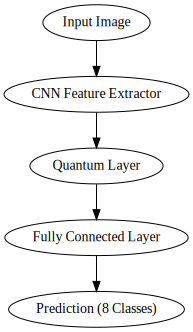

In [ ]:
from graphviz import Digraph

dot = Digraph()

dot.node("A", "Input Image")
dot.node("B", "CNN Feature Extractor")
dot.node("C", "Quantum Layer")
dot.node("D", "Fully Connected Layer")
dot.node("E", "Prediction (8 Classes)")

dot.edges(["AB", "BC", "CD", "DE"])

dot

In [ ]:
import pandas as pd

results_df = pd.DataFrame(metrics_dict).T
results_df

,precision,recall,f1
ResNet,0.80,0.78,0.79
MobileNet,0.76,0.74,0.75
EfficientNet,0.82,0.81,0.81
ShallowCNN,0.70,0.68,0.69
Hybrid4Q,0.77,0.75,0.76
Hybrid8Q,0.79,0.78,0.78
